# Class 4: Assessing impressive performance by evaluating and visualizing statistics

Plan for today is to o practice calculating descriptive statistics and creating visualizations to understanding what statistics values are impressive. In particular, we will use the matplotlib and seaborn packages to create visualziations such as box plots, histograms, density plots, and bee swarm plots, and we will use these visualizations to compare players from different eras. We will also practice calculating z-scores to compare players relative to their peers. 


In [119]:
import YData_baseball

YData_baseball.download_data("Lahman_2024u/Batting.csv")
YData_baseball.download_data("Lahman_2024u/People.csv")

The file `Batting.csv` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.
The file `People.csv` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.


In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part 0: Warm-up

As a warm-up exercise, let's partially recreate what we did in on lab 2 and write a function called `get_player_stats()` that takes a baseball players first and last year, and returns statistics only on this player. We will use this function to generate data we can use for the rest of the class. 

## Part 0.1

Data on players and their batting statistics is loaded as pandas DataFrames in the cell below. To start, please create a DataFrame called `batting_enhanced` that contains the batting statistics for all players, and includes a new column called `AVG` that contains the batting average for each player. The batting average should be calculated as the number of hits (`H`) divided by the number of at-bats (`AB`), rounded to three decimal places. The `batting_enhanced` file should also have merged on the from the `players` DataFrame so that we can easily access data on specific players using their first and last names. 


In [121]:
batting = pd.read_csv("Batting.csv")
players = pd.read_csv("People.csv")

In [122]:

batting_enhanced = batting.copy()


# Answer

batting_enhanced["AVG"] = np.round(batting_enhanced["H"]/batting_enhanced["AB"], 3)
batting_enhanced = batting_enhanced.merge(players, how='left', left_on='playerID', right_on='playerID')



## Part 0.2

Now please write the function `get_player_stats(first_name, last_name)` that takes as input arguments:

1. `first_name`: the first name of the player
2. `last_name`: the last name of the player

And returns a DataFrame that only contains the statistics for the player with the given first and last name. The DataFrame should contain the following columns: `playerID`, `yearID`, `stint`, `teamID`, `G`, `AB`, `R`, `H`, `2B`, `3B`, `HR`, `RBI`, `SB`, `CS`, `BB`, `SO`, and `AVG`. 

Once you have created this function, please use it to get the statistics for Mike Trout and store the result in a variable called `mike_trout`. 


In [123]:
def get_player_stats(first_name, last_name):
    
    player_data = batting_enhanced[batting_enhanced.nameFirst == first_name]
    player_data = player_data[player_data.nameLast == last_name]
    return player_data[['playerID', 'yearID', 'stint', 'teamID',  'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'AVG']]

mike_trout= get_player_stats("Mike", "Trout")  # 14 seasons
mike_trout 

,playerID,yearID,stint,teamID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,AVG
115310,troutmi01,2011,1,LAA,40,123,20,27,6,0,5,16.0,4.0,0.0,9,30.0,0.220
115311,troutmi01,2012,1,LAA,139,559,129,182,27,8,30,83.0,49.0,5.0,67,139.0,0.326
115312,troutmi01,2013,1,LAA,157,589,109,190,39,9,27,97.0,33.0,7.0,110,136.0,0.323
115313,troutmi01,2014,1,LAA,157,602,115,173,39,9,36,111.0,16.0,2.0,83,184.0,0.287
115314,troutmi01,2015,1,LAA,159,575,104,172,32,6,41,90.0,11.0,7.0,92,158.0,0.299
115315,troutmi01,2016,1,LAA,159,549,123,173,32,5,29,100.0,30.0,7.0,116,137.0,0.315
115316,troutmi01,2017,1,LAA,114,402,92,123,25,3,33,72.0,22.0,4.0,94,90.0,0.306
115317,troutmi01,2018,1,LAA,140,471,101,147,24,4,39,79.0,24.0,2.0,122,124.0,0.312
115318,troutmi01,2019,1,LAA,134,470,110,137,27,2,45,104.0,11.0,2.0,110,120.0,0.291
115319,troutmi01,2020,1,LAA,53,199,41,56,9,2,17,46.0,1.0,1.0,35,56.0,0.281


# Part 1: Descriptive statistics and plots

Let's now review how to calculate some descriptive statistics and create plots in Python. We will use these functions to determine what "good" performance looks like for a baseball players on lab 3. 


## 1.1 Percentiles

Recall that the $p^{th}$ percentile is the value of a quantitative variable which is greater than *p* percent of the data. We can get the value the $p^{th}$ percentile from a pandas Series using `.quantile()` method. For example, we can get the 90th percentile value using: `my_df["col"].quantile(.8)`. Alternatively, you can use `np.percentile(my_df["col"], 90)` to get the same result. 

**Question 1.1 (5 points)**: What is the 90th percentile value for home runs hit by Mike Trout? 


In [124]:

print(mike_trout.HR.quantile(.9))
print(mike_trout.AVG.quantile(.9))


# could also mention np.quantile()



40.7
0.3251


## 1.2 Five number summary

Recall that the five number summary consists of: 
1. The minimum value
2. The 25th percentile value (Q1)
3. The 50th percentile value (the median)
4. The 75th percentiel value (Q3) 
5. The maximum value

**Question 1.2 (7 points):** What is the 5 number summary for Mike Trout's home run numbers? 


In [125]:

# 5 number summary for all players
print("Mike Trout HR quantiles:")
print(mike_trout.HR.quantile([0, .25, .50, .75, 1]))
print(mike_trout.AVG.quantile([0, .25, .50, .75, 1]))


Mike Trout HR quantiles:
0.00     5.00
0.25    17.25
0.50    29.50
0.75    38.25
1.00    45.00
Name: HR, dtype: float64
0.00    0.22000
0.25    0.28150
0.50    0.29500
0.75    0.31425
1.00    0.33300
Name: AVG, dtype: float64


## 1.3 Boxplots 

Boxplots are a visualization of the five-number summary. We can create boxplots using the Matplotlib library's `plt.boxplot()` function and passing the function a sequence of numbers (e.g., an list, ndarray, or Series of numbers). 

**Question 1.3 (6 points):** Create a boxplot for Mike Trout home runs. Did he have any outlier seasons? If so, what could explain them? 


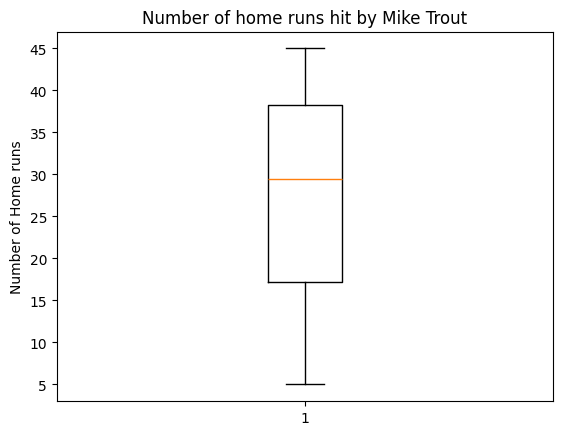

In [126]:
import matplotlib.pyplot as plt

# this code makes it so that figures appear in Jupyter notebooks, do not remove it!
%matplotlib inline



# make your boxplot here
plt.boxplot(mike_trout['HR']);
plt.ylabel("Number of Home runs");
plt.title("Number of home runs hit by Mike Trout");


## 1.4 Side-by-side box plots

Let's create side-by-side box plots comparing Mike Trout to Aaron Judge. 



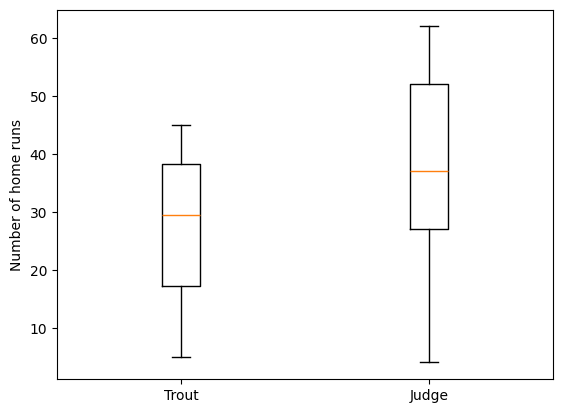

In [127]:
# Side-by-side box plots comparing Trout to Judge

aaron_judge = get_player_stats("Aaron", "Judge")  # 9 seasons

plt.boxplot([mike_trout.HR, aaron_judge.HR], tick_labels = ["Trout", "Judge"]);
plt.ylabel("Number of home runs");


## 1.5 Histograms

Histograms are a convenient way to view the full shape of a distribution. We can create a histogram using Matplotlib's `plt.hist()` function, where we pass the function a sequence of numeric data we want to plot as a histogram. 

**Question 3.6 (6 points):** Create a histogram of the batting average of all players in the `batting_enhanced` DataFrame. Use the `edgecolor` parameter to set the color of the edges of the bars in the histogram to black. Bonus: see if you can figure out how to create bins in the histogram such that the first bin has the number of players who hit 0 home runs, the second bin has the number of players who hit 1 home run, etc. and the y-axis displays the counts of the number of home runs. See: https://www.inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html

Also, create a histogram of Mike Trout's home runs. Why does this histogram look so bad? 


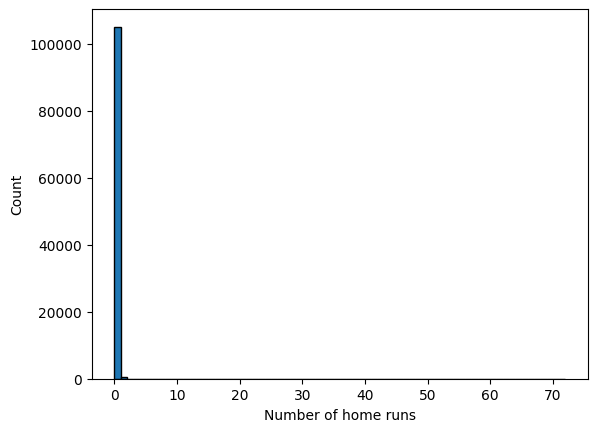

In [128]:
# Create a histogram of all batting averages

plt.hist(batting_enhanced['AVG'], edgecolor = "k", bins = np.arange(0,73,1));
plt.xlabel("Number of home runs");
plt.ylabel("Count");


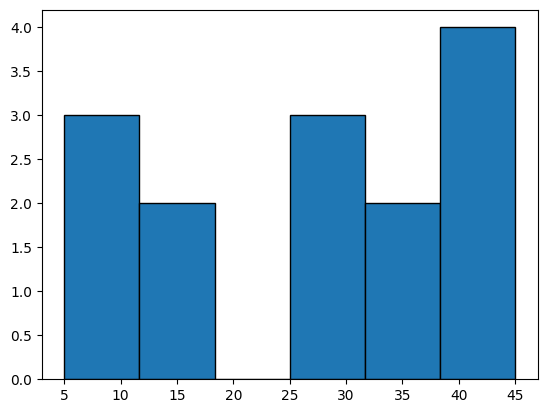

In [129]:
plt.hist(mike_trout['HR'], edgecolor = "k", bins = 6);

# Why does the histogram look so bad? 

# 1.6 Visulazing data using seaborn

We can also use Seaborn to create visualizations. Seaborn is a Python data visualization library based on Matplotlib that provides a high-level interface for drawing attractive statistical graphics. We can use Seaborn to create box plots, histograms, and other types of visualizations. 

We will focus on seaborn's "figure-level" functions, which are functions that create a figure and axes for us, so we do not need to create them ourselves. The functions we will focus on are:

1. `sns.catplot()`: This function is used to create categorical plots, such as box plots and bee swarm plots.
2. `sns.displot()`: This function is used to create distribution plots, such as histograms and kernel density estimates (KDE).
3. `sns.relplot()`: This function is used to create relational plots, such as scatter plots and line plots. 

Each of these functions takes a DataFrame as input and allows us to specify the x and y variables we want to plot, the kind of plot we want to create, and other parameters such as color and marker style by mapping column names to these plot properties.  

Let's create the following visualizations:

1. A bee swarm plot of Mike Trout's home runs using `sns.catplot()` where we set the `kind` argument to be "swarm".  
2. A kernel density plot of Mike Trout's home runs using `sns.displot()` where we set the `kind` argument to be "kde".  
3. A line plot of Mike Trout's home runs over the years using `sns.relplot()` where we set the `kind` argument to be "line" and the `marker` argument to be "o".  
4. A scatter plot of Mike Trout's batting average vs. home runs using `sns.relplot()`.   

Which visualization do you think is the best for visualizing Mike Trout's home runs? 


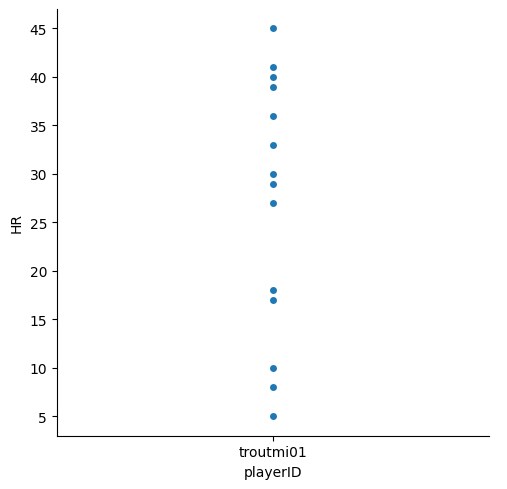

In [130]:
# 1. Create a bee swarm plot of Mike Trout's home runs
# The options for the kind argument are: "strip", "swarm", "box", "violin", "point", "bar", and "boxen"

sns.catplot(mike_trout, x="playerID", y="HR", kind="swarm");


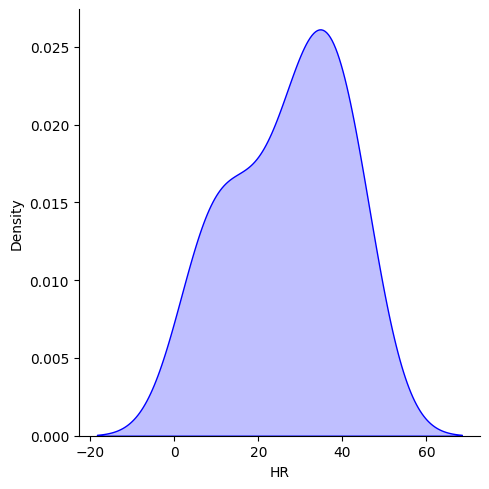

In [131]:
# 2. Create a kernel density plot of Mike Trout's home runs
# The options for the kind argument are: "hist", "kde", and "ecdf"

sns.displot(mike_trout, x = "HR", kind = "kde", fill = True, color = "blue");


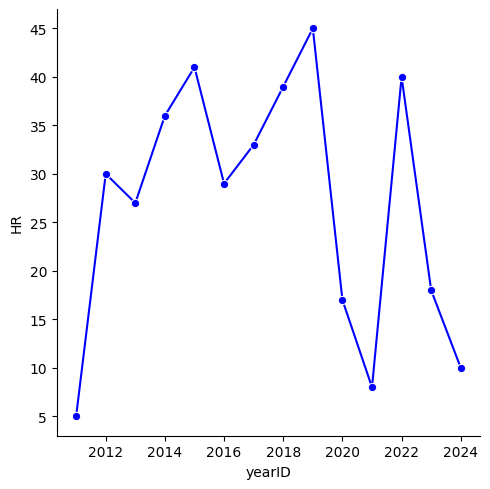

In [132]:
# 3. A line plot of Mike Trout's home runs over the years

sns.relplot(mike_trout, x="yearID", y="HR", kind="line", color = "blue", marker = "o");

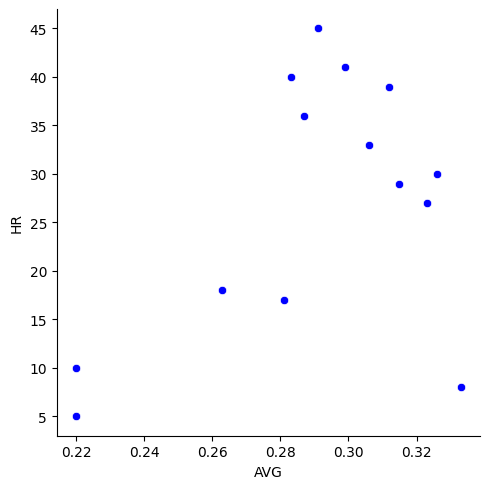

In [133]:
# 4. A scatter plot of  Mike Trout's home runs vs. batting average

sns.relplot(mike_trout, x="AVG", y="HR", kind = "scatter", color = "blue", marker = "o");

# 2 Comparing players from eras

Above we saw how to calculate descriptive statistics and create visualizations for a single player, and we compared two players who played during similar year ranges. 

Let's now compare two players two Red Sox hitting greats, Wade Boggs and Ted Williams, who played in different eras!

## 2.1 Getting Ted and Wade's data

To start, let's use our `get_player_stats()` function to get the batting statistics for Wade Boggs and Ted Williams. 

**Question 2.1** Should we look at their data from all seasons or should we limit the data to only particular seasons? 

In [134]:

wade_data = get_player_stats("Wade", "Boggs")
ted_data = get_player_stats("Ted", "Williams")

wade_data = wade_data.query("AB > 300")   
ted_data = ted_data.query("AB > 300")    

display(ted_data)

display(wade_data)


,playerID,yearID,stint,teamID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,AVG
123205,willite01,1939,1,BOS,149,565,131,185,44,11,31,145.0,2.0,1.0,107,64.0,0.327
123206,willite01,1940,1,BOS,144,561,134,193,43,14,23,113.0,4.0,4.0,96,54.0,0.344
123207,willite01,1941,1,BOS,143,456,135,185,33,3,37,120.0,2.0,4.0,147,27.0,0.406
123208,willite01,1942,1,BOS,150,522,141,186,34,5,36,137.0,3.0,2.0,145,51.0,0.356
123209,willite01,1946,1,BOS,150,514,142,176,37,8,38,123.0,0.0,0.0,156,44.0,0.342
123210,willite01,1947,1,BOS,156,528,125,181,40,9,32,114.0,0.0,1.0,162,47.0,0.343
123211,willite01,1948,1,BOS,137,509,124,188,44,3,25,127.0,4.0,0.0,126,41.0,0.369
123212,willite01,1949,1,BOS,155,566,150,194,39,3,43,159.0,1.0,1.0,162,48.0,0.343
123213,willite01,1950,1,BOS,89,334,82,106,24,1,28,97.0,3.0,0.0,82,21.0,0.317
123214,willite01,1951,1,BOS,148,531,109,169,28,4,30,126.0,1.0,1.0,144,45.0,0.318


,playerID,yearID,stint,teamID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,AVG
10226,boggswa01,1982,1,BOS,104,338,51,118,14,1,5,44.0,1.0,0.0,35,21.0,0.349
10227,boggswa01,1983,1,BOS,153,582,100,210,44,7,5,74.0,3.0,3.0,92,36.0,0.361
10228,boggswa01,1984,1,BOS,158,625,109,203,31,4,6,55.0,3.0,2.0,89,44.0,0.325
10229,boggswa01,1985,1,BOS,161,653,107,240,42,3,8,78.0,2.0,1.0,96,61.0,0.368
10230,boggswa01,1986,1,BOS,149,580,107,207,47,2,8,71.0,0.0,4.0,105,44.0,0.357
10231,boggswa01,1987,1,BOS,147,551,108,200,40,6,24,89.0,1.0,3.0,105,48.0,0.363
10232,boggswa01,1988,1,BOS,155,584,128,214,45,6,5,58.0,2.0,3.0,125,34.0,0.366
10233,boggswa01,1989,1,BOS,156,621,113,205,51,7,3,54.0,2.0,6.0,107,51.0,0.330
10234,boggswa01,1990,1,BOS,155,619,89,187,44,5,6,63.0,0.0,0.0,87,68.0,0.302
10235,boggswa01,1991,1,BOS,144,546,93,181,42,2,8,51.0,1.0,2.0,89,32.0,0.332


## 2.2 Comparing Ted and Wade with box plots 

Let's now compare Wade Boggs and Ted Williams in terms of their batting average. We will use box plots to visualize the distribution of their batting averages, and we will also look at the year when each player had their highest batting average. 

**Question 2.2** Who seems like the better hitter in terms of their batting average? 


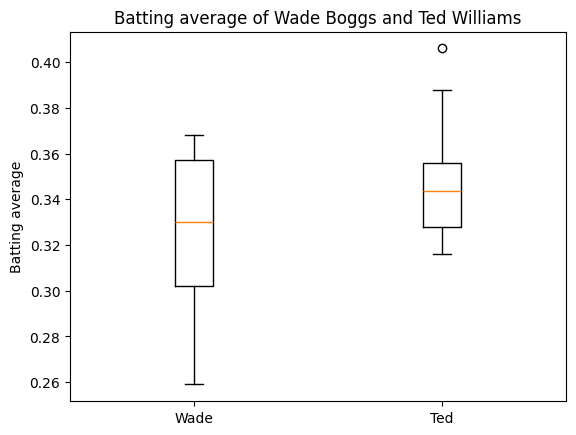

In [135]:
# Box plots and bee swarm plots of Ted and Wade

plt.boxplot([wade_data['AVG'], ted_data['AVG']], tick_labels = ["Wade", "Ted"]);
plt.ylabel("Batting average");
plt.title("Batting average of Wade Boggs and Ted Williams");


## 2.3 Looking a batting averages in Ted and Wade's best seasons

Let's also look the distribution of batting averages in Ted and Wade's best seasons. Let's do this as follows:

a. Find the year when Wade Boggs had his highest batting average and the year when Ted Williams had his highest batting average (for seasons that had over 300 at-bats). 

b. Create a new DataFrame called `batting_300AB` that only contains the batting statistics for players who had over 300 at-bats. 

c. `data_best_seasons` that only contains the batting statistics for the years that Ted and Wade had their highest batting averages. This DataFrame should also only contains players who had over 300 at-bats. 

d. Visualize the distribution of batting averages in the `data_best_seasons` DataFrame using a `displot()` with a kernel density estimate (KDE). 

**Question 2.3**  Does the distribution in batting averages look similar between these two seasons? 


In [136]:
# a. Display the years when Wade and Ted had their highest BA

display(wade_data.sort_values(by='AVG', ascending=False).head(1))

display(ted_data.sort_values(by='AVG', ascending=False).head(1))


,playerID,yearID,stint,teamID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,AVG
10229,boggswa01,1985,1,BOS,161,653,107,240,42,3,8,78.0,2.0,1.0,96,61.0,0.368


,playerID,yearID,stint,teamID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,AVG
123207,willite01,1941,1,BOS,143,456,135,185,33,3,37,120.0,2.0,4.0,147,27.0,0.406


In [137]:
# b. Create batting_300AB DataFrame which has the data from all players who had over 300 at-bats

batting_300AB = batting_enhanced[(batting_enhanced['AB'] >= 300)]

In [138]:
# c. Create data_best_season DataFrame which has the data from the year's that Wade and Ted's best seasons (for only players that had at least 300 at-bats)

data_best_season = batting_300AB[(batting_300AB ['yearID'] == 1941) | (batting_300AB ['yearID'] == 1985)]


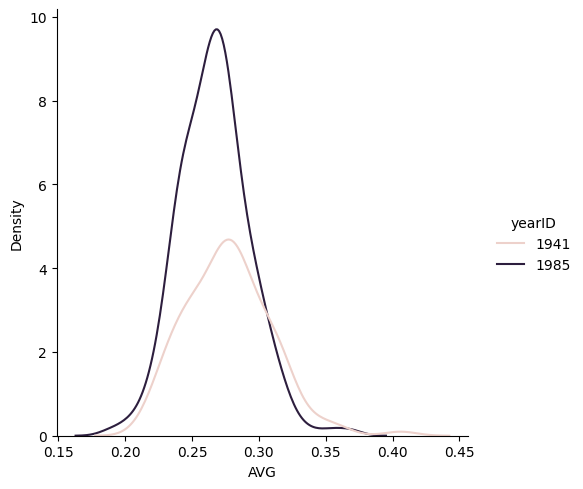

In [139]:
# d. Compare the data from the season when Wade Boggs and Ted Williams had their best batting averages

# Use a displot (with kind = "kde") to visualize the distribution of batting averages in the best seasons of Wade Boggs and Ted Williams
sns.displot(data_best_season, x="AVG", hue = "yearID", kind = "kde",);

# You can try other visualizations as well


## 2.4 How has batting average changed over time? 

Let's explore how batting averages have changed over time. We can do this by looking at the maximum batting average for each year. 

**Question 2.4** Does it appear that batting average has changed over time? If so, does comparing Wade and Ted's battering averages seem like a fair comparison? 


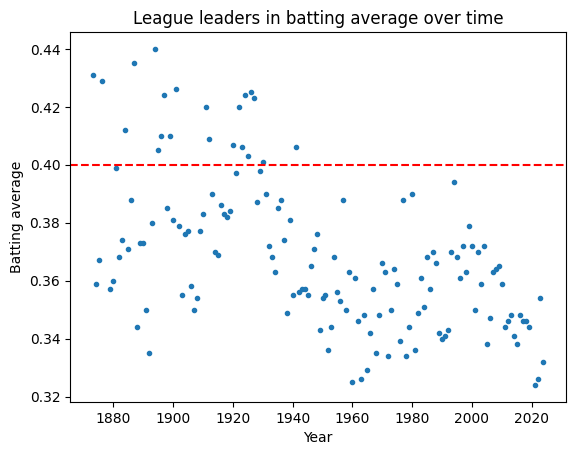

In [140]:
max_BA = batting_300AB.groupby('yearID')['AVG'].max()

plt.plot(max_BA, '.');
plt.xlabel("Year");
plt.ylabel("Batting average");
plt.title("League leaders in batting average over time");
plt.axhline(y=0.4, color='r', linestyle='--', label='0.4 batting average');

# 3. Comparing players to their peers using z-scores

As we saw in the previous exercise, the values for the league leaders in batting average has changed over the last 140 years. Thus, if we wanted to compare players across several decades, just using their raw statistics would be problematic. One way to do a fairer comparison across decades is to compare players relative to their peers who played during the same year. We can then say that a player is outstanding if he is much better than his peers who played at the same time. 

A z-score is one way to compare a player relative to his peers. The z-score measures how many standard deviations a player is above the mean performance and is given by the formula:

$z_i = \frac{x_i - \bar{x}}{s}$

Where we have: 

- $x_i$: is the raw statistic value for our player of interest.
- $\bar{x}$: is the mean statistic values for players who played during the same time period.
- s: is the standard deviation of the statistic values for players who played during the same time period.

In the following exercise we will compare the z-scores for the batting average of Ted Williams and Wade Boggs to see who has the most outstanding batting average relative to their peers. 


## 3.1 Calculating mean and standard deviation of statistics

As we can see in the formula for the z-score above, in order to calculate a z-score we need to first calculate the mean and standard deviation for the statistic of interest. Since we want to calculate the z-scores separately for each year, we will need to calculate these means and standard deviations separately for each year. 

One way we can do this by:

a. Using DataFrame `.groupby()` to group the DataFrame by year.

b. Selecting only the "AVG" column to create a grouped Series that has just the batting averages.

c. Applying the `.mean()` to the grouped Series that has the mean batting average for each year, and saving the results to the variable `mean_AVG`. 

d. Repeating these steps to create a grouped Series that has the standard deviation of batting averages for each year, and saving the results to the variable `sd_AVG`. 

Let's do this now!


In [141]:

mean_AVG = batting_300AB.groupby('yearID')["AVG"].mean()
sd_AVG = batting_300AB.groupby('yearID')["AVG"].std()

mean_AVG


yearID
1873    0.371600
1874    0.306900
1875    0.296867
1876    0.319429
1879    0.274846
          ...   
2019    0.263355
2021    0.256557
2022    0.251306
2023    0.255634
2024    0.249275
Name: AVG, Length: 149, dtype: float64

## 3.2 Calculating z-scores for Wade and Ted

Let's now calculate the z-scores for Wade Boggs and Ted Williams' batting averages. We can do this using the following steps:

1. Set the index of the `wade_data`  DataFrames to be the year using `.set_index("yearID")`.

2. Subtract the mean batting average for each year from Wade Boggs' batting averages using the `mean_AVG` Series we created above. Then divide by the standard deviation of batting averages for each year using the `sd_AVG` Series we created above. Since the `mean_AVG` and `sd_AVG` Series have the `yearID` as its Index, this will automatically subtract the mean batting average (and divide by the standard deviation) for each year from Wade Boggs' batting averages. 

3. Finally, we can use the `.dropna()` method to remove any NaN values that may have been created if a player did not play in a given year, and save the results to the name `wade_zscores`.

4. Repeat this process for Ted Williams' batting averages and save the results to the name `ted_zscores`. 




In [142]:
wade_zscores = ((wade_data.set_index("yearID")["AVG"] - mean_AVG)/sd_AVG).dropna()
ted_zscores = ((ted_data.set_index("yearID")["AVG"] - mean_AVG)/sd_AVG).dropna()


## 3.3 Side-by-side box plots of Ted and Wade's z-scored batting averages

Now let's visualize their z-scores to see who appears to have the better batting average relative to his peers by creating side-by-side box plots. 

**Question 3.3** Based on this data visualization, who appears to have the better batting average relative to his peers? 


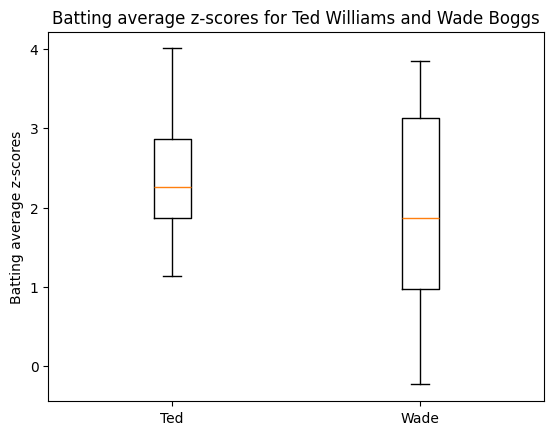

In [143]:
plt.boxplot([ted_zscores, wade_zscores], tick_labels= ["Ted", "Wade"]);
plt.ylabel("Batting average z-scores");
plt.title("Batting average z-scores for Ted Williams and Wade Boggs");


In [144]:
%%capture

# You can run this code to covert this Jupyter notebook into a pdf
!quarto render class_04_answers.ipynb --cache-refresh --to pdf 